<a href="https://colab.research.google.com/github/itinasharma/MachineLearning/blob/main/PCA_elbow_to_choose_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

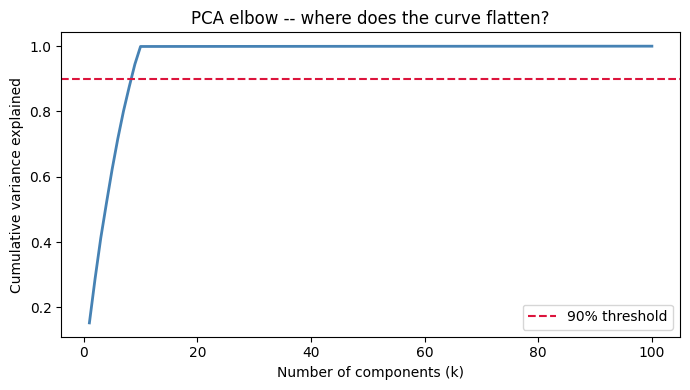

Components for 90% variance: 9
Recommended embedding size:  16


In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import math

np.random.seed(0)
n_samples, n_features = 2000, 100

# Simulate data: true structure is 10-dimensional
Z_true = np.random.randn(n_samples, 10)
A      = np.random.randn(10, n_features)
X      = Z_true @ A + 0.1 * np.random.randn(n_samples, n_features)

# Run PCA on all 100 features
pca = PCA(n_components=n_features)
pca.fit(X)
cumvar = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(range(1, n_features + 1), cumvar, color="steelblue", lw=2)
plt.axhline(0.90, color="crimson", linestyle="--", label="90% threshold")
plt.xlabel("Number of components (k)")
plt.ylabel("Cumulative variance explained")
plt.title("PCA elbow -- where does the curve flatten?")
plt.legend()
plt.tight_layout()
plt.show()

# Find elbow: smallest k covering 90% of variance
k_90 = int(np.argmax(cumvar >= 0.90)) + 1
embed_size = 2 ** math.ceil(math.log2(k_90))
print(f"Components for 90% variance: {k_90}")
print(f"Recommended embedding size:  {embed_size}")